In [110]:
import tarfile  
import os

# extract tar file
with tarfile.open('./cifar-10-python.tar.gz') as file:
    file.extractall(path='./data')

data_dir = './data/cifar-10-batches-py'
# see what in the folder dataset
print(os.listdir(data_dir))

C:\Users\OS\AppData\Local\Temp\ipykernel_15700\249676253.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  file.extractall(path='./data')


['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']


In [111]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def load_batches(batch):
  with open(batch, 'rb') as f:
    dict = pickle.load(f, encoding = 'bytes')
    data = dict[b'data']
    labels = dict[b'labels']
    return data, labels

# read test batch
X_test, y_test = load_batches(os.path.join(data_dir, 'test_batch'))
X_test = np.array(X_test)
y_test = np.array(y_test)

# read list of 10 class names
with open(os.path.join(data_dir, 'batches.meta'), 'rb') as f:
  meta = pickle.load(f, encoding='utf-8')
  label_names = meta['label_names']

print(label_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [112]:
import torch
from torchvision.transforms import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# reshape images
X_test = X_test.reshape(-1, 3, 32, 32)

# normalize data
# define mean and std for CIFAR-10 normalization
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# define valid and test transform
test_transform = transforms.Compose([
  transforms.ToPILImage(),# convert to PIL Image
  transforms.ToTensor(),# convert the PIL image to tensor and scale pixel values to [0, 1]
  transforms.Normalize(mean, std),# normalize the tensor using the dataset's mean and std
])

# custom Dataset class
class CIFARDataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    img = self.images[idx].transpose(1, 2, 0)  # convert from (C, H, W) to (H, W, C)
    if self.transform:
      img = self.transform(img)
    label = self.labels[idx]
    return img, label

# create Dataset
test_dataset = CIFARDataset(X_test, y_test, transform = test_transform)

# create DataLoader
test_loader = DataLoader(test_dataset)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (10000, 3, 32, 32)
y_test shape: (10000,)


In [113]:
from torch import nn
import torch.optim as optim

def create_MLP_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # flat data -> 1D
    nn.Flatten(),

    # layer 1
    nn.Linear(3072, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    # layer 2
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    # layer 3 - output layer
    nn.Linear(256, 10)
  )
  return model

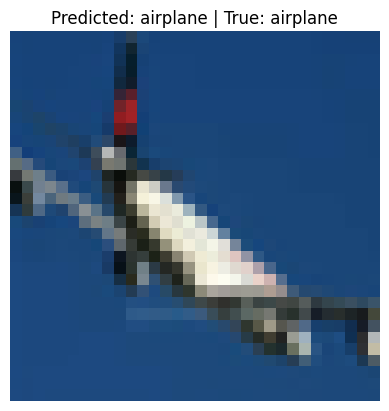

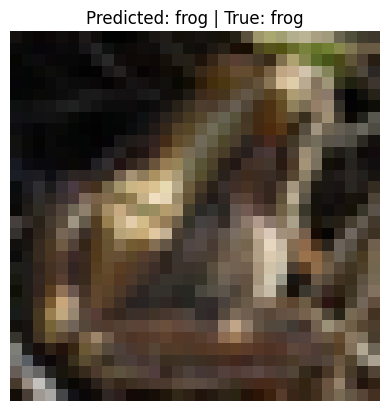

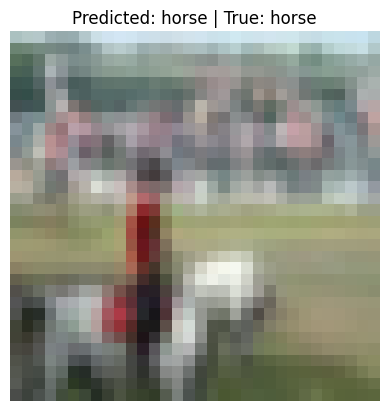

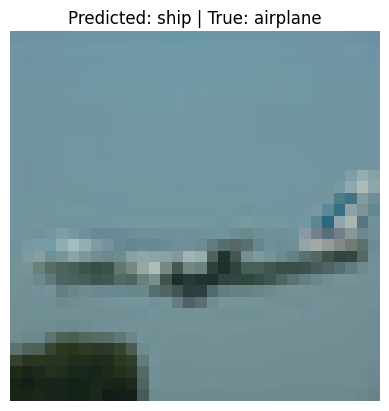

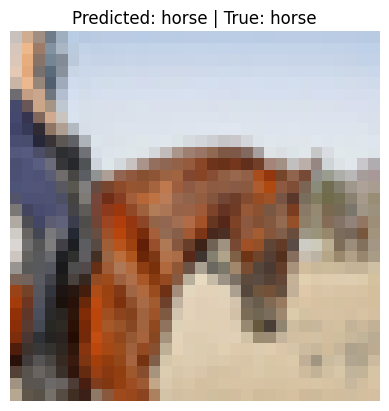

In [114]:
MLP_model = create_MLP_model()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MLP_model.load_state_dict(torch.load('MLP_model.pth', map_location = device))
MLP_model.to(device)
MLP_model.eval()

# Get random indices for 5 images
random_indices = torch.randint(0, len(test_dataset), (5,))

with torch.inference_mode():
    for idx in random_indices:
        images, labels = test_dataset[idx]
        images = images.unsqueeze(0)  # Add batch dimension
        outputs = MLP_model(images)
        _, predicted = torch.max(outputs, 1)

        img = images[0].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
        img = std * img + mean  # unnormalize
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Predicted: {label_names[predicted[0]]} | True: {label_names[labels]}")
        plt.axis('off')
        plt.show()

In [115]:
def create_CNN_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # CNN-1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 32 x 16 x 16

    # CNN-2
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 64 x 8 x 8

    # CNN-3
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 128 x 4 x 4

    nn.Flatten(),

    # Dense layer
    nn.Linear(128*4*4, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(dropout_rate),

    # output layer
    nn.Linear(512, 10)
  )
  return model

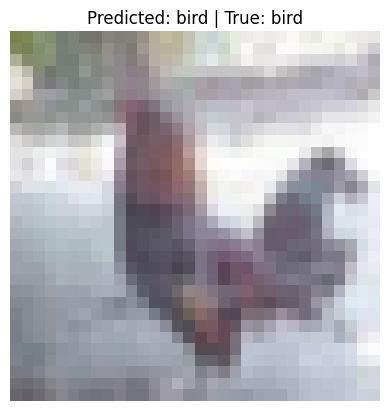

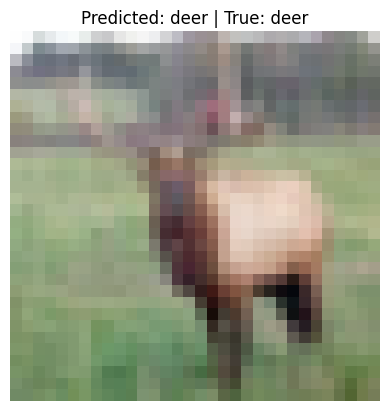

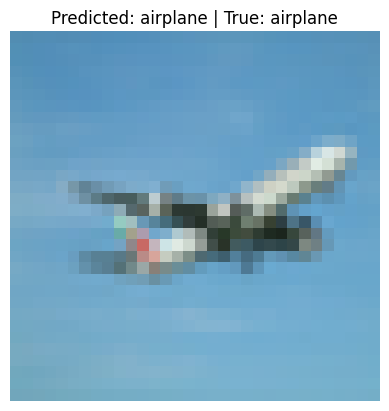

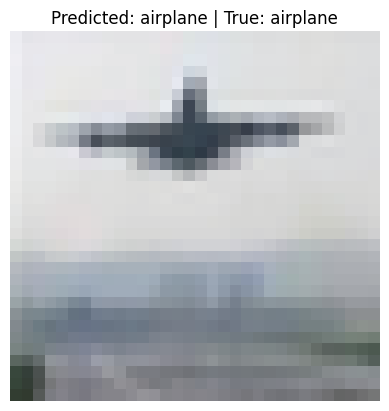

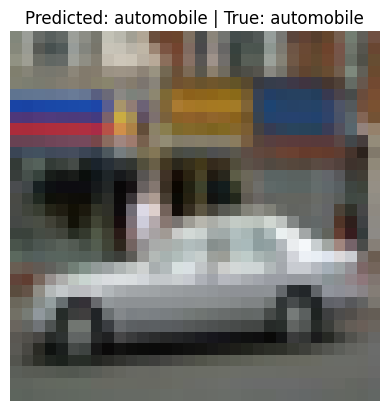

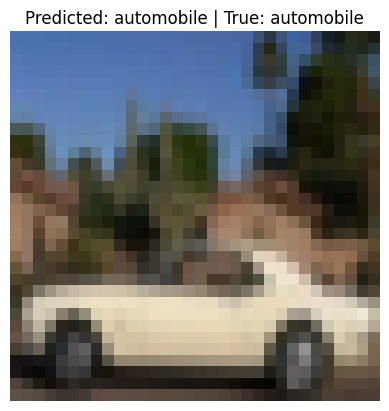

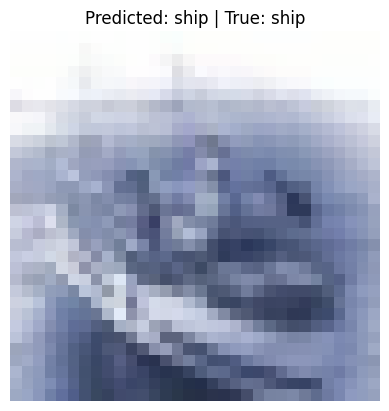

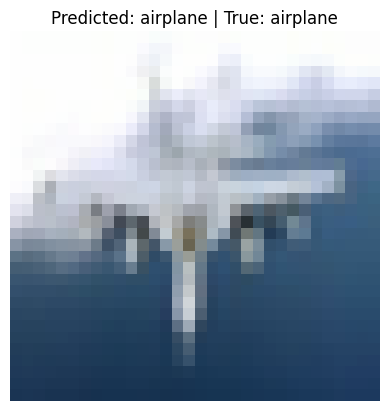

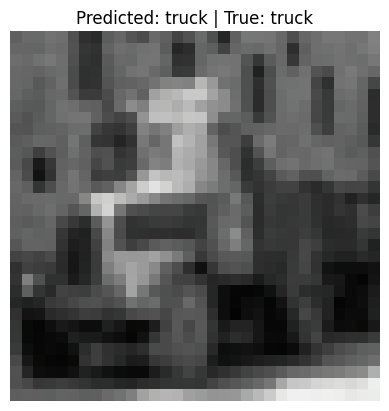

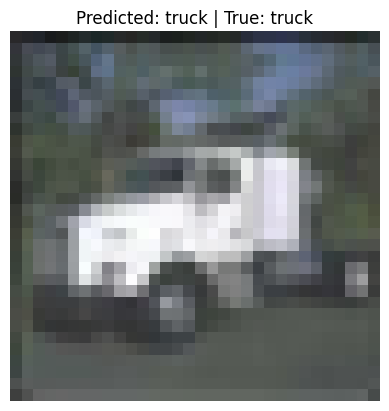

In [116]:
CNN_model = create_CNN_model()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CNN_model.load_state_dict(torch.load('CNN_model.pth', map_location = device))
CNN_model.to(device)
CNN_model.eval()

# Get random indices for 10 test images
random_indices = torch.randint(0, len(test_loader.dataset), (10,))

with torch.inference_mode():
    for idx in random_indices:
        # Get a single random image and label
        image, label = test_loader.dataset[idx.item()]
        image = image.unsqueeze(0)  # Add batch dimension
        
        outputs = CNN_model(image)
        _, predicted = torch.max(outputs, 1)

        img = image[0].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
        img = std * img + mean  # unnormalize
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Predicted: {label_names[predicted[0]]} | True: {label_names[label]}")
        plt.axis('off')
        plt.show()